# Вычислительная математика
## 5.3 Уравнения в частных производных. Метод конечных разностей

Содержание семинара:

- __Общая формулировка УРЧП (напоминание)__
    - Линейные УРЧП. Классификация
    - Об отличиях типов
- __Параболические уравнения__
    - Принцип дискретизации
    - Одномерный случай (по координате)
        - Постоянные коэффициенты
        - Метод прогонки (на примере схемы Кранка-Никольсон)
    - Переменные коэффициенты (консерватизм)
    - Квазилинейный случай (неоднородный)
    - Многомерный случай (по координате)
- __Эллиптические уравнения__
    - Пример решения уравнения Пуассона в 2d. Прямой метод.
    - Итерационный метод - сведение к уравнению теплопроводности
- __Гиперболические уравнения__
- __Сходимость разностных схем__
    - Сходимость = Аппроксимация + Устойчивость
    - Примеры исследования схем на аппроксимацию
    - Спектральный признак устойчивости. Примеры.
- __Задание краевых условий на криволинейной границе__
- __Домашнее задание__

## Общая формулировка УРЧП
### Линейные УРЧП. Классификация

__Определение.__ __Линейное УРЧП__ от двух переменных это уравнение вида

$$
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}+D(x, y) \frac{\partial u}{\partial x}+E(x, y) \frac{\partial u}{\partial y}+F(x, y) u+G(x, y)=0
$$

что эквивалентно следующей записи

$$
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}=\hat{\mathbf{L}} u
$$

Цель - __найти $u(x,y)$ с заданными граничными условиями__.

__Примечание.__ Если бы какие-то из коэффициентов зависели бы ещё дополнительно от $u$, $\frac{\partial u}{\partial x}$ или $\frac{\partial u}{\partial y}$, то уравнение называлось бы __квазилинейным__.

Относительно $A(x, y), B(x, y)$ и $C(x, y)$ можно подвести следующую классификацию УРЧП:

$$
\begin{array}{|c|c|c|}
\hline \text { Classification } & \text { Condition } & \text { Example of PDE } \\
\hline \text { Parabolic } & B^2-4 A C=0 & \text { Heat equation } \\
\hline \text { Hyperbolic } & B^2-4 A C>0 & \text { Wave equation } \\
\hline \text { Elliptic } & B^2-4 A C<0 & \text { Laplace equation } \\
\hline \begin{array}{c}
\text { Mix Type } \\
\text { (parabolic/hyperbolic/elliptic) }
\end{array} & \begin{array}{c}
\text { Satisfied all/more than one of the } \\
\text { above conditions }
\end{array} & \begin{array}{c}
\text { Heat/Wave/Laplace/Poisson } \\
\text { equation }
\end{array} \\
\hline
\end{array}
$$

__Примечание.__ Классификация __локальна__, т.к. коэффициенты зависят от точки плоскости в которой мы сейчас находимся, и знак Condition может меняться в рассматриваемой области - отсюда и смешанный тип.

__Примечание.__ Названия типов формально берутся от квадратичной формы характеристического уравнения. Все типа существенно различаются по свойствам, что приводит к их отдельному рассмотрению. В частности, решения эллиптического уравнения всегда гладкие, тогда как решения гиперболических уравнений этим свойством не обладают.

__Примечание.__ В случае бОльшего числа переменных, типы сохраняются:

$$\sum_{i=1}^n \sum_{j=1}^n a_{i, j} \frac{\partial^2 u}{\partial x_i \partial x_j} \; + \; F(u,\; \frac{\partial u}{\partial x_1},\; \frac{\partial u}{\partial x_2}, \cdots, \; \frac{\partial u}{\partial x_n})=0$$

- __Elliptic__: Все собственные значения $a_{i,j}$ имеют одинаковый знак. [Laplace-Eq.]
- __Parabolic__: Одно из собственных значений зануляется. [Diffusion-Eq.]
- __Hyperbolic__: Одно собственное значение имеет другой знак. [Wave-Eq.]
- __Ultrahyperbolic__: Более чем одно собственное значение имеют другой знак относительно других.
- __Mixed__

__Примечание.__ Отличия могут показаться несущественными, но на практике они столь велики, что решения каждого типа считается отдельной областью. В этом семинаре рассмотрим подробнее параболический тип.

## __Параболический тип__
- Явный __эволюционный во времени__ процесс. См. характеристики для понимания. Нулевое собственное число отвечает времени.
- Явная зависимость от времени.
- Решаются как при заданных начальных условиях, так и при краевых.
- "Негладкости" и "разрывы" возможны, но __сглаживаются__ со временем.

Примеры:

- Уравнение теплопроводности (диффузии)

$$
\frac{\partial u}{\partial t}-a^2 \Delta u=f(\mathbf{r}, t)
$$

- Уравнение анизотропной диффузии (квазилинейное - страшно, да?)

$$
\frac{\partial u(\mathbf{r}, t)}{\partial t}=\sum_{i=1}^3 \sum_{j=1}^3 \frac{\partial}{\partial x_i}\left[D_{i j}(u, \mathbf{r}) \frac{\partial u(\mathbf{r}, t)}{\partial x_j}\right]
$$

### Пример решения параболической задачи

__Определение.__ Задача уравнения диффузии (теплопроводности) ставится следующим образом:

$$
\frac{\partial u}{\partial t}=a \frac{\partial^2 u}{\partial x^2}+f(t, x), \quad t \in[0, \mathrm{~T}], \quad x \in[0, X]
$$

В линейном случае $a=a(x, t)>0$. В квазилинейном случае $a=a(u, x, t)>0$ и $f=f(u, x, t)$.

Для того, чтобы задача была поставлена корректно, необходимо задать __начальное условие__ по времени:

$$
u(0, x)=u_0(x), \quad t=0
$$

и __граничные условия__ (в одном из трёх родов) по координате:

Условия первого рода:
$$
\begin{aligned}
& u=\varphi_1(t), \quad x=0 \\
& u=\varphi_2(t), \quad x=X
\end{aligned}
$$
и условия второго рода:
$$
\begin{aligned}
& -\frac{\partial u}{\partial x}=\varphi_1(t), \quad x=0 \\
& \frac{\partial u}{\partial x}=\varphi_2(t), \quad x=X
\end{aligned}
$$
Условия третьего рода:
$$
\begin{aligned}
& -A_1 \frac{\partial u}{\partial x}+B_1 u=\varphi_1(t), \quad x=0 \\
& A_2 \frac{\partial u}{\partial x}+B_2 u=\varphi_2(t), \quad x=X 
\end{aligned}
$$


Метод конечных разностей основан на дискретизации функции и всех производных, как мы уже делали это раньше в одномерном случае. Только теперь дискретная функция - это какая-то многомерная матрица $u_m^n \stackrel{ideal\, world}{=} u(t_n, x_m)$. Здесь и далее индекс сверху всегда обозначает время, а индексы снизу координаты.

### Схемы для уравнения теплопроводности с постоянными коэффициентами

Приведём некоторые разностные схемы (дискретизации), работающие для константного $a$. Каждой дискретизации можно сопоставить картинку (__шаблон__), показывающую, какие конкретно узлы $u_m^n$ связаны уравнением.

- __Явная схема__

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=a \cdot \frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}+f_m^n
$$

Устойчива при $\sigma=\frac{a \tau}{h^2} \leq \frac{1}{2}$ и порядок аппроксимации $O\left(\tau, h^2\right)$.

![original image](https://cdn.mathpix.com/snip/images/xtiCm2IM3BHT7wxj_SwQWxeVx7PsSpfkREDDfd8HTa0.original.fullsize.png)



- __Неявная схема__

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=a \frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+f_m^n
$$

Устойчива при при любых $\tau, h$, порядок аппроксимации $O\left(\tau, h^2\right)$.

![original image](https://cdn.mathpix.com/snip/images/x-G5iQxJhtFoTRAHR4oye8L7TUqmAhxhvskt1tfE934.original.fullsize.png)


- __Смешанная шеститочечная схема__

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=a\left[\xi \frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+(1-\xi) \frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}\right]+f_m^n
$$

Где вес $\xi \in[0,1]$ - заранее задаваемое нами число - отвечает за смесь явной и неявной производных по координате. Определяется эмпирически или ищется наиболее оптимальное значение $\xi$ можно отыскать из "максимизации" устойчивости (об этом позже).

![original image](https://cdn.mathpix.com/snip/images/L6KyBzKOYwWPUSTUICIjVHedMdrTpnWhm7hh8J0jj18.original.fullsize.png)


- __Схема Кранка-Никольсон__ - смешанная схема при $\xi =\frac{1}{2}$

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{a}{2}\left(\frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+\frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}\right)+f_m^n
$$

Схема устойчива при любых шагах $\tau, h$ и имеет порядок аппроксимации $O\left(\tau, h^2\right)$. Эта схема, в отличие от двух предыдущих, __не является монотонной__, т.е. она может давать осцилляции разностного происхождения на решениях, имеющих большие градиенты.

- __Трёхслойная схема__ - вводим "смесь" явной и неявной схемы также для производной по времени

$$
\begin{aligned}
& \frac{(1-\eta)\left(u_m^{n+1}-u_m^n\right)}{\tau}+\eta \frac{u_m^n-u_m^{n-1}}{\tau}- \\
& -a\left[(1-\xi) \frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}+\xi \frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}\right]=f_m^n
\end{aligned}
$$

При $\eta=0,5, \quad \xi=1 \quad$ ее порядок аппроксимации равен $O\left(\tau^2, h^2\right)$. Недостатком схемы является более высокий порядок разностного уравнения по времени, чем порядок исходного дифференциального, следовательно, необходимость ставить дополнительное условие на $u_t^{\prime}(0, x)$.

![original image](https://cdn.mathpix.com/snip/images/1KchTxOdnkBI81jS9fpI3uTPFT91AAENfY-gWSDdRTE.original.fullsize.png)

__Примечание.__ Неявные схемы решаются путём построения СЛАУ на все пространственные точки в новом слое.

__Примечание.__ Эти схемы легко перенести на многомерный случай или на любое другое параболическое уравнение. Главное помнить, что они "хорошо" работают только __при постоянных коэффициентах__. Если коэффициенты зависят от времени и координат, то их строят исходя из нужных законов сохранения.

Следующий анимация демонстрирует процесс решения разностной схемы на шаблоне Кранка-Николсон.

In [1]:
#!pip install gdown
import gdown
from IPython.display import HTML

HTML(gdown.download('https://drive.google.com/uc?id=1Co4v72cPOzWH6BESds1OSAjq2KByZvCS', 'anim.html', quiet=True))

Черные точки - это то, что мы уже знаем (граничные условия + найденные). Белые - ещё не знаем.

Видим, что в процессе решения шаблон как бы идёт по сетке, касаясь как черных точек, так и белых (которые после этого становятся зелёными). Каждый кадр соответствует записыванию уравнения, в котором есть как известные (чёрные) точки, так неизвестные.

Когда схема доходит до правого края, мы имеем 8 линейных уравнений на 8 неизвестных (все зелёные точки) - эта система имеет решение, а значит мы можем найти все точки на данной слою.

Как-то так и работает метод конечных разностей.

__Примечание.__ Из этой визуализации понятно, как выбирать граничные условия. Если бы, например, не было чёрных точек справа (это соответствует знанию нами $u(t, 1)$ для любого момента времени), то мы бы никогда не получили $N$ уравнений на $N$ неизвестных. Тем не менее, схему всё равно можно было бы запустить, зная 2 слоя слева (это соответствует знанию граничных условий $u(t, 0)$ и $\cfrac{\partial u}{\partial x}(t, 0)$).



__Примечание.__ Заметим, что если бы использовали явную схему, то не пришлось бы возиться с составлением и решением системы. Следующий пример демонстрирует простоту реализации явного метода.

In [2]:
# Пример явной схемы f = 0

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Parameters
a = 1.0
L = 1.0
T = 0.2
Nx = 100
Nt = 100000
h = L/(Nx-1)
tau = T/(Nt-1)
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)

# Initial and boundary conditions
def u0(x):
    return  1 + np.sin(2*np.pi*x/L)**2 + np.sin(np.pi*x/L)

def ul(t):
    return 1

def ur(t):
    return 1

# Finite difference method
r = a*tau/h**2
u = np.zeros((Nx, Nt))
 
u[:, 0] = u0(x)

for n in range(Nt-1):
    
    u[0, n+1] = ul(t[n+1])
    u[-1, n+1] = ur(t[n+1])
    
    for m in range(1, Nx-1):
        u[m, n+1] = u[m, n] + r*(u[m-1, n] - 2*u[m, n] + u[m+1, n]) 

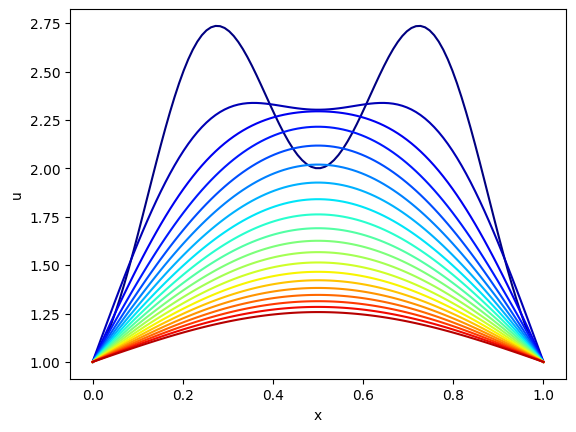

In [3]:
# Plot every 100th timestep
fig, ax = plt.subplots()
for n in range(0, Nt, 5000):
    color = cm.jet(n/Nt)
    ax.plot(x, u[:, n], color=color, label=f"t={t[n]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("u")
norm = plt.Normalize(0, T)
cmap = cm.jet
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
#cbar = fig.colorbar(sm)
#bar.ax.set_ylabel("Time")
plt.show()

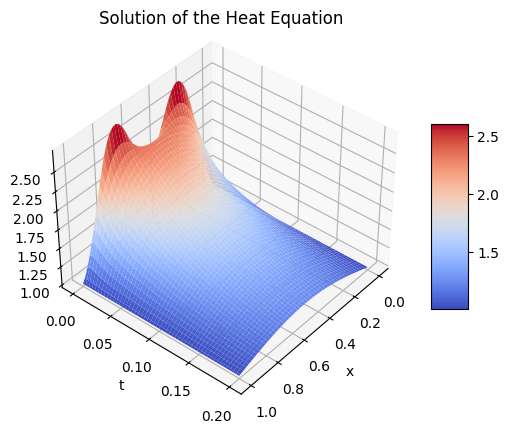

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D surface plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=40, azim=40)
X, Y = np.meshgrid(x, t[::100])
Z = u.T[::100, :]
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
ax.set_title('Solution of the Heat Equation')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

### Как составлять и решать СЛАУ для неявных шаблонов

У явных схем помимо простоты есть ещё одна отличительная особенность - они почти никогда не работают. Надо научиться решать УРЧП неявными схемами. 

Рассмотрим, например, __схему Кранка-Никольсон__ 

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{a}{2}\left(\frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+\frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}\right)+f_m^n
$$

Хотим её реализовать. Пусть также заданы  начальные и граничные  условия:

$$
u_m^0=u_0(x_m)
$$

$$
u_0^n=u_{left}(t_n)
$$

$$
u_{N_x-1}^n=u_{right}(t_n)
$$

Хотим записать нашу разностную задачу в каноническом виде (для фиксированных $n$ и $n+1$ - по ним здесь суммирования не идёт)

$$
A_{sm} u_m^{n+1}=B_{sm} u_m^n+b_s^n
$$

где $A, B$ и $b$ пишутся исходя из вида уравнения. Перенесём все слагаемые с $n+1$ слоя влево:

$$
\left(1+\frac{a \tau}{h^2}\right) \cdot u_m^{n+1}-\frac{a \tau}{2 h^2} u_{m-1}^{n+1}-\frac{a \tau}{2 h^2} u_{m+1}^{n+1}=u_m^n+\frac{a \tau}{2h^2}\left(u_{m-1}^n-2 u_m^n+u_{m+1}^n\right)+\tau f_m^n
$$

Введём так называемое __число Куранта__ $r=\frac{a \tau}{2h^2}$. Тогда уравнение:

$$
\left(1+2r\right) \cdot  u_m^{n+1}-r \cdot  u_{m-1}^{n+1}-r \cdot u_{m+1}^{n+1}=u_m^n+r\cdot \left(u_{m-1}^n-2 u_m^n+u_{m+1}^n\right)+\tau f_m^n
$$

Откуда видим выражения на искомые операторы (c учётом граничных условий):

Оператор $A_{s, m}$:

$$
\quad
$$

$$
A_{0, 0} = 1, \quad
A_{N_x-1, N_x-1} = 1
$$

$$
A_{m-1, m} = -r , \quad
A_{m, m} = 1+2r, \quad
A_{m+1, m} = -r, \quad m \in[1, N_x-2]
$$

$$
A_{\text{other}, m} = 0
$$

$$
\quad
$$

$$
\mathbf{A} =
\begin{pmatrix}
1 & 0 & 0& 0 & \cdots & 0 & 0 \\
-r & 1+2r & -r & 0 & \cdots & 0 & 0 \\
0 & -r & 1+2r & -r & \cdots & 0 & 0 \\
0 & 0 & -r & 1+2r & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & \cdots & 0 & -r & 1+2r & -r \\
0 & 0 & \cdots & 0 & 0 & 0 & 1 \\
\end{pmatrix}
$$

$$
\quad
$$

Оператор $B_{s, m}$ (при более сложных граничных условиях первая и последняя строчки могут быть ненулевыми):

$$
\quad
$$

$$
B_{m-1, m} = r , \quad
B_{m, m} = 1-2r, \quad
B_{m+1, m} = r, \quad m \in[1, N_x-2]
$$

$$
B_{\text{other}, m} = 0
$$

$$
\quad
$$

$$
\mathbf{B} =
\begin{pmatrix}
0 & 0 & 0 & 0 & \cdots & 0 & 0 \\
r & 1-2r & r & 0 & \cdots & 0 & 0\\
0 & r & 1-2r & r & \cdots & 0 & 0\\
0 & 0 & r & 1-2r & \cdots & 0 & 0\\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots\\
0 & 0 & \cdots & 0 & r & 1-2r & r\\
0 & 0 & \cdots & 0 & 0 & 0 & 0\\
\end{pmatrix}
$$

$$
\quad
$$

Столбец $b_s^n$:

$$
\quad
$$

$$
b_0^n=u_{\text{left}}(t_{n+1}), \quad
b_{N_x-1}^n=u_{\text{right}}(t_{n+1})
$$

$$
b_s^n=\tau \cdot f^n_s
$$

$$
\quad
$$

$$
\mathbf{b}^n =
\begin{pmatrix}
u_{\text{left}}(t_{n+1}) \\
\tau \cdot f_1^n \\
\tau \cdot f_2^n \\
\vdots \\
\tau \cdot f_{N_x-2}^n \\
u_{\text{right}}(t_{n+1}) \\
\end{pmatrix}
$$

$$
\quad
$$

На каждом шаге можно использовать np.linalg.solve относительно неизвестного столбца $u_s^{n+1}$, но это __плохо-обусловленная__ задача, т.е. при большой размерности ошибка решения СЛАУ станет слишком большой. 

Эффективнее использовать алгоритм __прогонки__.

Обозначим всю известную правую часть за столбец $F_s^n = B_{sm} u_m^n+b_s^n$. Тогда решаем систему на $u_m^{n+1}$:

$$
A_{sm} u_m^{n+1}=F_s^n 
$$

с трёхдиагональной матрицей $A$. Обозначим далее для простоты формул $x_i = u_i^{n+1}$.

Эта система равносильна следующим формулам (построчные равенства, там где вылезли за границы просто присваиваем нули):

$$
A_i x_{i-1}+B_i x_i+C_i x_{i+1}=F_i
$$

Ищем решение в виде реккуренты (т.е. перепишем задачу в терминах поиска коэффициентов $\alpha_i, \beta_i$ - как только они найдены, применяя эту же формулу найдём реккурентно все $x_i$):

$$
x_i=\alpha_{i+1} \cdot x_{i+1}+\beta_{i+1}, \quad \text { where } i=N_x-2, N_x-3, \ldots, 0
$$

При этом $\alpha_i, \beta_i$ __не должны__ зависеть искомых $x_i$. Начальные члены этих последовательностей можно определить нулевыми $\alpha_0=\beta_0=0$.

Используя это соотношение, выразим $x_{i-1}$ и $x_i$ через $x_{i+1}$ и подставим в изначальное уравнение:

$$
\left(A_i \alpha_i \alpha_{i+1}+B_i \alpha_{i+1}+C_i\right) \cdot x_{i+1}+A_i \alpha_i \beta_{i+1}+A_i \beta_i+B_i \beta_{i+1}-F_i=0
$$

Беря частную производную слева от $x_{i+1}$ понимаем, что множитель в скобках должен равняться нулю. А тогда и всё остальное в уравнении должно зануляться:

$$
\left\{\begin{array}{l}
A_i \alpha_i \alpha_{i+1}+B_i \alpha_{i+1}+C_i=0 \\
A_i \alpha_i \beta_{i+1}+A_i \beta_i+B_i \beta_{i+1}-F_i=0
\end{array}\right.
$$

Отсюда следуют явно заданные реккуренты на $\alpha_i, \beta_i$

$$
\left\{\begin{aligned}
\alpha_{i+1} & =\frac{-C_i}{A_i \alpha_i+B_i} \\
\beta_{i+1} & =\frac{F_i-A_i \beta_i}{A_i \alpha_i+B_i}
\end{aligned}\right.
$$

С начальным условием (из  $\alpha_0=\beta_0=0$):

$$
\left\{\begin{array}{l}
\alpha_1=-C_0 / B_0 \\
\beta_1=F_0 / B_0
\end{array}\right.
$$

Теперь, когда мы знаем $\alpha_i, \beta_i$, легко реккурентно посчитать искомый вектор неизвестных:

$$
\left\{\begin{array}{l}
x_i=\alpha_{i+1} x_{i+1}+\beta_{i+1}, \quad i=Nx-2 \ldots 0 \\
x_{Nx-1}=\cfrac{F_{Nx-1}-A_{Nx-1} \beta_{Nx-1}}{B_{Nx-1}+A_{Nx-1} \alpha_{Nx-1}}
\end{array}\right.
$$

100%|█████████████████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 3252.32it/s]


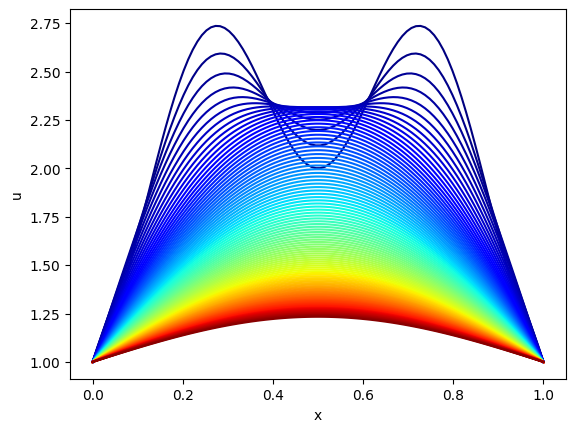

In [5]:
# Пример схемы Кранка-Никольсон с f = 0 методом прогонки

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from numba import njit
from tqdm import tqdm


def TDMA(A,B,C, F): # Прогонка
    # A, B, C, F - просто числовые последовательности, НЕ матрицы

    A = np.insert(A, 0, 0)
    
    n = len(F)
    x = np.zeros(n)
    alpha = np.zeros(n)
    beta = np.zeros(n)
    
    alpha[1] = -C[0]/B[0]
    beta[1] = F[0]/B[0]

    for i in range(2, n):
        alpha[i] = -C[i-1]/(A[i-1]*alpha[i-1] + B[i-1])
        beta[i] = (F[i-1] - A[i-1]*beta[i-1])/(A[i-1]*alpha[i-1] + B[i-1])
        

    x[n-1] = (F[n-1] - A[n-1]*beta[n-1])/(B[n-1] + A[n-1]*alpha[n-1])
    
    
    for i in range(n-1, 0, -1):  # помним, что последнее значение не кушает
        x[i - 1] = alpha[i]*x[i] + beta[i]
        
    
    return x

# Parameters
a = 1.0
L = 1.0
T = 0.2
Nx = 100
Nt = 100 # Как же мало нам понадобилось шагов по времени!
h = L/(Nx-1)
tau = T/(Nt-1)
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)

# Initial and boundary conditions
def u0(x):
    return  1 + np.sin(2*np.pi*x/L)**2 + np.sin(np.pi*x/L)
def ul(t):
    return 1
def ur(t):
    return 1
# Define the source term
def f(t, x):
    return 0

# Initialize the solution matrix
u = np.zeros((Nt, Nx))

# Set the initial condition
u[0, :] = u0(x)

# Set the boundary conditions
u[:, 0] = ul(t)
u[:, -1] = ur(t)

# Set up the matrix for the Crank-Nicolson scheme
r = a*tau/(2*h**2)
A = np.zeros((Nx, Nx))
for i in range(1, Nx-1): # ПОмним, что последний индекс в цикле НЕ кушается
    A[i, i] = 1 + 2*r
    A[i, i-1] = -r
    A[i, i+1] = -r
A[0, 0] = 1
A[-1, -1] = 1

B = np.zeros((Nx, Nx))
for i in range(1, Nx-1): # ПОмним, что последний индекс в цикле НЕ кушается
    B[i, i] = 1 - 2*r
    B[i, i-1] = r
    B[i, i+1] = r


# Time stepping with the Crank-Nicolson scheme
for n in tqdm(range(1, Nt)):
    
    b = np.zeros(Nx)
    
    b[0] = ul(t[n])
    b[-1] = ur(t[n])
    b[1: -1] = tau*f(t[n-1], x[1:-1])
    
    #print(b)
    
    F = B @ u[n-1] + b

    #u[n, :] = np.linalg.solve(A, F) # Не сработает для большого Nx
    u[n, :] = TDMA(A.diagonal(offset = -1),
                     A.diagonal(offset = 0),
                     A.diagonal(offset = 1),
                     F)

    
# Plot every 100th timestep
fig, ax = plt.subplots()
for n in range(0, Nt, 1):
    color = cm.jet(n/Nt)
    ax.plot(x, u[n, :], color=color, label=f"t={t[n]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("u")
norm = plt.Normalize(0, T)
cmap = cm.jet
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
#cbar = fig.colorbar(sm)
#cbar.ax.set_ylabel("Time")
plt.show()


### Построение разностных схем для УРЧП с переменными коэффициентами (Консерватизм)

__Определение.__ Схема называется __консервативной__, если в дискретизованной задаче выполняются те же законы сохранения (первые интегралы), что и в дифференциальной. Вспомните про количество независимых первых интегралов в системе ДУ. 

Как правило, если коэффициенты в линейном УРЧП зависят от координат $a=a(x, t)$, то для обеспечения консерватизма системы необходимо __строить разностную задачу исходя из требуемых законов сохранения__

На примере того же однородного уравнения диффузии (теплопроводности)

$$
\frac{\partial u}{\partial t}=a \frac{\partial^2 u}{\partial x^2}, \quad t \in[0, \mathrm{~T}], \quad x \in[0, X]
$$

Его законом сохранения (первым интегралом) является уравнение непрерывности на тепловой поток $W=-a(t, x) \frac{\partial u}{\partial x}$:

$$
\frac{\partial u}{\partial t}+\frac{\partial W}{\partial x}=0
$$

или, в интегральной форме,

$$
\int_S\left(\frac{\partial u}{\partial t}+\frac{\partial W}{\partial x}\right) d t d x=\oint_{\Gamma} u d x-W d t=0
$$

Любое из этих уравнений должно быть выполнено всегда и где угодно. Удобно взять самое последнее и обеспечить его для самого маленького контура в системе (для любого другого контура оно будет выполнено автоматически по линейности):

$$
u_m^n \cdot h-W_{m+1 / 2}^{n+1 / 2} \cdot \tau-u_m^{n+1} \cdot h+W_{m-1 / 2}^{n+1 / 2} \cdot \tau=0
$$

Это же можно получить из дифференциальной формы закона сохранения

$$
\frac{u_m^{n+1}-u_m^n}{\tau}+\frac{W_{m+1 / 2}^{n+1 / 2}-W_{m-1 / 2}^{n+1 / 2}}{h}=0
$$


Здесь взяли __промежуточные узлы__ на $W$, т.к. такой приём, как правило, даёт лучшую устойчивость __при переменных коэффициентах__ (напоминаю $W=-a(t, x) \frac{\partial u}{\partial x}$):

$$
W_{m+1 / 2}^{n+1 / 2}=-\frac{1}{2}\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}+a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}\right)
$$

$$
W_{m-1 / 2}^{n+1 / 2}=-\frac{1}{2}\left(a_{m-1 / 2}^n \frac{u_{m}^n-u_{m-1}^n}{h}+a_{m-1 / 2}^{n+1} \frac{u_{m}^{n+1}-u_{m-1}^{n+1}}{h}\right)
$$

Подставляя это в дискретизованный закон сохранения, имеем нашу __консервативную__ численную схему:

$$
\begin{aligned}
& \quad \frac{u_m^{n+1}-u_m^n}{\tau}-\frac{1}{2 h}\left[\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}-a_{m-1 / 2}^n \frac{u_m^n-u_{m-1}^n}{h}\right)+\right. \\
& \left.+\left(a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^{n+1} \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)\right]=0
\end{aligned}
$$

Она получилось шеститочечной.

__Примечание.__ В случае неоднородности просто добавляем её. Опять же, чем на бОльших узлах зададим, тем лучше, но не очень критично, если честно.

$$
\begin{aligned}
& \quad \frac{u_m^{n+1}-u_m^n}{\tau}-\frac{1}{2 h}\left[\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}-a_{m-1 / 2}^n \frac{u_m^n-u_{m-1}^n}{h}\right)+\right. \\
& \left.+\left(a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^{n+1} \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)\right]=f_m^n
\end{aligned} 
$$

### Квазилинейный случай

Рассмотрим случай зависимости коэффициентов от от искомой функции $a=a(u)>0$ и $f=f(u)$ - т.е. простая квазилинейность. При зависимости этих коэффициентов ещё и от $x, t$ обобщение тривиально на основе предыдущего пункта.

Т.к. коэффициенты переменные, то опять-таки используем __промежуточные узлы__.

- Явная схема с нелинейностью на нижнем слое

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{1}{h}\left[a_{m+1 / 2}^n \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^n \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right]+f_m^n
$$

где $a_{m+1 / 2}^n$ может быть вычислена одним из следующим способов:

1. $a_{m+1 / 2}^n=\frac{1}{2}\left(a\left(u_m^n\right)+a\left(u_{m+1}^n\right)\right)$,

2. $a_{m+1 / 2}^n=a\left(\cfrac{u_m^n+u_{m+1}^n}{2}\right)$,

3. $a_{m+1 / 2}^n=a\left(\cfrac{2 u_m^n u_{m+1}^n}{u_m^n+u_{m+1}^n}\right)$,

4. $a_{m+1 / 2}^n=\cfrac{2 a\left(u_m^n\right) a\left(u_{m+1}^n\right)}{a\left(u_m^n\right)+a\left(u_{m+1}^n\right)}$.

На следующем слое опять-таки решается СЛАУ на неизвестные коэффициенты методом прогонки (полученная система будет трёхдиагональной).

Недостаток схемы заключается в необходимости выполнения условия, ограничивающего шаг по времени $\tau\left\|f_u^{\prime}\right\|<<1$ для обеспечения устойчивости.

- Неявная схема с нелинейностью на нижнем слое

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{1}{h}\left(a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^{n+1} \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)+f_m^{n+1}
$$

Нужна когда условие $\tau\left\|f_u^{\prime}\right\|<<1$ невыполнимо.



Решать большую систему нелинейных уравнений ну уж очень не хочется, так что здесь, как правило, используют линеаризацию

$$
f\left(u_m^{i+1}\right)=f\left[u_m^i+\left(u_m^{i+1}-u_m^i\right)\right] \approx f\left(u_m^i\right)+f_u^{\prime}\left(u_m^i\right)\left(u_m^{i+1}-u_m^i\right)
$$


$$
a\left(u_m^{i+1}\right)=a\left[u_m^i+\left(u_m^{i+1}-u_m^i\right)\right] \approx a\left(u_m^i\right)+a_u^{\prime}\left(u_m^i\right)\left(u_m^{i+1}-u_m^i\right)
$$

И алгоритм тот же самый - решить СЛАУ на верхнем уровне методом прогонки.

__Примечание.__ В случае общей квазилинейности по $a=a(u, x, t)$ просто берём предыдущий параграф и всё, что связано с зависимостью от $u$ считаем по формулам из этого. Шеститочечная схема, например:

$$
\begin{aligned}
& \frac{u_m^{n+1}-u_m^n}{\tau}-\frac{1}{2 h}\left[\left(a_{m+1 / 2}^n \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^n\frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)+\right. \\
& \left.+\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}-a_{m-1 / 2}^n \frac{u_m^n-u_{m-1}^n}{h}\right)\right] =f\left(u_m^n\right)+f_u^{\prime}\left(u_m^n\right)\left(u_m^{n+1}-u_m^n\right)
\end{aligned}
$$

где $a_{m+1 / 2}^n$ может быть вычислена одним из следующим способов:

1. $a_{m+1 / 2}^n=\frac{1}{2}\left(a\left(u_m^n, \; x_m, \;t_n\right)+a\left(u_{m+1}^n, \; x_{m+1}, \;t_n\right)\right)$,

2. $a_{m+1 / 2}^n=a\left(\cfrac{u_m^n+u_{m+1}^n}{2},\; \cfrac{x_m+x_{m+1}}{2},\; t_n\right)$,

3. $a_{m+1 / 2}^n=a\left(\cfrac{2 u_m^n u_{m+1}^n}{u_m^n+u_{m+1}^n},\; \cfrac{2 x_m x_{m+1}}{x_m+x_{m+1}}, \; t_n\right)$,

4. $a_{m+1 / 2}^n=\cfrac{2 \cdot a_m^n \cdot a_{m+1}^n}{a_m^n+a_{m+1}^n}$.

### Многомерный  (по координате) случай

Численное решение даже простейших уравнений параболического типа сильно усложняется, если в задаче имеется в наличии более одного пространственного измерения. Условие устойчивости для многомерных схем накладывает столь жесткие ограничения на шаги по времени, что расчет по ним практически невозможен (на прошлом семинаре мы как раз использовали явную схему - работало всё очень долго). Необходимо применять __неявные схемы__. 

Пусть решаем

$$
\frac{\partial u}{\partial t}=\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2} + f(x, y, t)
$$

Неоднородностью $f(x, y, t)$ пока пренебрежём (см. примечание в конце пункта).

Дискретизуем задачу в виде

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\mathbf{\Lambda}_1 u_{m l}^{n+1}+\mathbf{\Lambda}_2 u_{m l}^{n+1}
$$

где 

$$
\mathbf{\Lambda}_1 u_{m l}^{n+1}=\frac{u_{m-1, l}^{n+1}-2 u_{m, l}^{n+1}+u_{m+1, l}^{n+1}}{h_x^2}
$$

$$
\mathbf{\Lambda}_2 u_{m l}^{n+1}=\frac{u_{m, l-1}^{n+1}-2 u_{m l}^{n+1}+u_{m, l+1}^{n+1}}{h_y^2}
$$

Схема выглядит следующим образом:



<img src="https://cdn.mathpix.com/snip/images/FJHOqGofKfhY-XPw7r0mmRTtFRRzh6D9Qj0m0PvWy14.original.fullsize.png" width="400">

Можно на каждом шаге решать систему на весь следующий слой из $N^2$ уравнений на $N^2$ неизвестных, но это не очень эффективно, т.к. аналога метода прогонки для такой задачи нет.

Можно предложить схему __расщепления по направлениям__, или локально одномерную схему (__метод дробных шагов__), где на каждом шаге по времени мы последовательно решаем две разностные задачи сначала на ~, потом на $n+1$:

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 \tilde{u}_{m l}
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\mathbf{\Lambda}_2 u_{m l}^{n+1}
$$

<img src="https://cdn.mathpix.com/snip/images/f7rGZA0niueT2LKUSXckgkxXhZed9DKWCNl54OhXA7Q.original.fullsize.png" width="400">

На каждом из промежуточных шагов мы сути решаем одномерную задачу для строки или столбца матрицы $u_{ml}$ столько раз, чтобы всю её заполнить. Сначала делаем в одном направлении (по одной координате), потом в другом (по другой координате). Таким образом применим хорошо обусловленный алгоритм прогонки.

Порядок аппроксимации этой схемы $O\left(\tau, h_x^2, h_y^2\right)$.

__Примечание.__ Обобщение на бОльшие размерности тривиально - просто больше промежуточных слоёв.


__Примечание.__ Порядок аппроксимации по времени легко увеличить до второго, придав слою ~ смысл $n+\frac{1}{2}$ шага по времени:

$$
\begin{aligned}
& \frac{u_{m l}^{n+1 / 2}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1\left[\xi u_{m l}^{n+1 / 2}+(1-\xi) u_{m l}^n\right] \\
& \frac{u_{m l}^{n+1}-u_{m l}^{n+1 / 2}}{\tau}=\boldsymbol{\Lambda}_2\left[\xi u_{m l}^{n+1}+(1-\xi) u_{m l}^{n+1 / 2}\right]
\end{aligned}
$$

__Примечание.__ Если уравнение неоднородно, то правую часть легко засунуть в схему, например:

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 \tilde{u}_{m l}+\frac{1}{2} f_{m l}^n
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\boldsymbol{\Lambda}_2 u_{m l}^{n+1}+\frac{1}{2} f_{m l}^{n+\frac{1}{2}}
$$

## __Эллиптический тип__
- Обычно нет временной зависимости - несколько пространственных координат. Нет эволюции во времени - процесс __стационарный__.
- Решаются как краевые задачи при заданных краевых условиях.
- Решения гладкие, если позволяют краевые условия.

Примеры:

- Уравнение Пуассона (Лапласа при $f=0$):
$$
\sum_{i=1}^n \frac{\partial^2}{\partial x_i^2} u(x)=f(x)
$$


### Пример решения уравнения Пуассона в 2d. Прямой метод.

Мы хотим решить уравнение Пуассона:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x, y)$$

в $[0,1] \times [0,1]$ - квадратная область с граничными условиями

$$u(x,0) = x, \quad u(x,1) = x - 1, \quad u(0,y) = -y, \quad u(1,y) = 1 - y.$$

__Примечание.__ Даже если область другая, можем произвести замену координат к квадрату. Или выпендриваться, о дискретизации нетривиальных граничных условий позже.

Дискретизуем производные. Возьмём формулы второго порядка аппроксимации по каждой из осей.

$$
\frac{u_{i-1, j}-2 u_{i, j}+u_{i+1, j}}{h^2}+\frac{u_{i, j-1}-2 u_{i, j}+u_{i, j+1}}{h^2}=f_{i j}
$$

Отсюда получаем уравнение на центральную точку (т.к. знаем края логично двигаться в центр)

$$
u_{i, j}=\frac{1}{4}\left(u_{i+1, j}+u_{i-1, j}+u_{i, j+1}+u_{i, j-1}-h^2 f\left(x_i, y_j\right) \right)
$$

Решаем наш "диффур" на сетке $(i, j)$. При этом знаем все граничные точки на сетке, и есть уравнение связи точек на "кресте" (т.н. шаблон крест).

__Примечание.__ Зная 4 точки из "креста", можно найти пятую, выразив из уравнения. При другой дискретизации производных получили бы другие шаблоны.

<p style="text-align:center;"><img src="https://cdn.mathpix.com/snip/images/-UXjZDVom7s7c5dIXtHLmEohWS_-GpjJxhKpLpartBQ.original.fullsize.png" width="300">


Такая схема обладает 2-м порядком аппроксимации (достаточно просто разложить по Тейлору вокруг точек $x_i$ и $y_j$ и убедиться, что дифференциальное уравнение выполняется с точностью $O(h^2)$).

Для решения задачи (определения всех внутренних точек, зная только краевые) можно составить большую СЛАУ на все внутренние точки. Грубо говоря, будем идти нашим крестом по всем внутренним точкам начиная с нижнего ряда и до верхнего по порядку. В каждом случае, будем запоминать, какая функциональная связь между коэффициентами. Когда дойдём до верхнего ряда, пойдём назад и "расшифруем" все пройдённые точки.

Звучит сложно, да? Это называется __прямой метод__. Объясним его подробнее.

Хотим свести дифференциальную задачу к дискретной, заданной в тензорном (дискретизованном) виде (__с учётом краевых условий__):

$$
L_{i,j,k,l}\cdot u_{k,l}=b_{i,j}
$$

Во всех "внутренних" точках квадрата оно имеет тот самый дискретизованный вид, который мы написали ранее:

$$
b_{i,j}=f_{i,j}, \quad i,j \in [1, \cdots,n-1]
$$

$$
L_{i,j,k,l}\cdot u_{k,l}=\frac{u_{i-1, j}-2 u_{i, j}+u_{i+1, j}}{h^2}+\frac{u_{i, j-1}-2 u_{i, j}+u_{i, j+1}}{h^2}, \quad i,j \in [1, \cdots,n-1]
$$

$$
L_{i,j,k,l}\cdot u_{k,l}=\frac{1}{h^2}\left(u_{i-1, j}+u_{i+1, j} +u_{i, j-1}+u_{i, j+1}\right)-\frac{4}{h^2}u_{i, j}, \quad i,j \in [1, \cdots,n-1]
$$

А тогда просто вспомнив, как работает сумма, для внутренних $i,j \in [1, \cdots,n-1]$ выполнено

$$
\left\{\begin{array}{l}
L_{i, j, i+1, j}=L_{i, j, i-1, j}=L_{i, j, i, j+1}=L_{i, j, i, j-1}=\frac{1}{h^2} \\
L_{i, j, i, j}=-\frac{4}{h^2} \\
L_{i, j, \text { other }}=0
\end{array}\right.
$$

Также в это тензорное уравнение мы хотим занести краевые условия. Достаточно следующего:

$$
b_{0,j}=\varphi_{\text{left}}(y_j)
$$

$$
L_{0, j, k, l}\cdot u_{k, l} = u_{0, j} 
$$

что эквивалентно

$$
\left\{\begin{array}{l}
L_{0, j, 0, j}=1 \\
L_{0, j, \text{other}}=0
\end{array}\right.
$$

Для остальных трёх краевых условий аналогично.

Теперь, когда мы определили все элементы $L_{i,j,k,l}$ и $b_{i,j}$, остаётся только решить тензорное уравнение относительно $u_{i,j}$:

$$
L_{i,j,k,l}\cdot u_{k,l}=b_{i,j}
$$

В этом могут помочь методы numpy ;).

In [6]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def boundary(grid):
    x = np.linspace(0,1,len(grid))
    
    grid[0,:]  = -x
    grid[:,-1] = x-1
    grid[-1,:] = 1-x
    grid[:,0]  = x
    

def poisson_direct(gridsize, set_boundary):
    L = np.zeros(shape=(gridsize, gridsize, gridsize, gridsize),
                 dtype='d')
    
    b = np.zeros(shape=(gridsize, gridsize),
                 dtype='d')
    
    dx = 1.0 / (gridsize - 1)
    
    # discretized differential operator
    for i in range(1,gridsize-1):
        for j in range(1,gridsize-1):
            L[i,j,i-1,j] = L[i,j,i+1,j] = L[i,j,i,j-1] = L[i,j,i,j+1] = 1/dx**2
            L[i,j,i,j] = -4/dx**2
    
    # boundary conditions
    for i in range(0,gridsize):
        L[0,i,0,i] = L[-1,i,-1,i] = L[i,0,i,0] = L[i,-1,i,-1] = 1
    
    # set the boundary values on the right side
    set_boundary(b)
    
    return np.linalg.tensorsolve(L,b) 

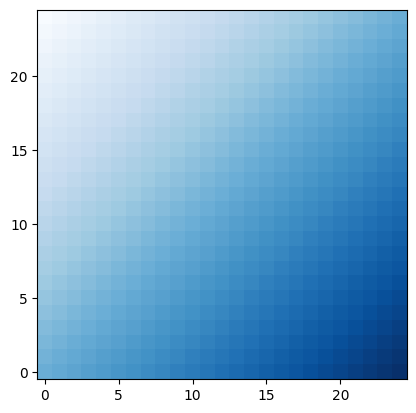

In [7]:
def showsol(sol):
    plt.imshow(sol.T,cmap=mpl.cm.Blues,interpolation='none',origin='lower')

sol = poisson_direct(25, boundary) # Сетка из 25 точек
showsol(sol)

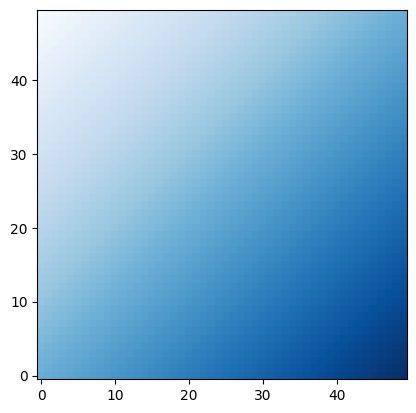

In [8]:
showsol(poisson_direct(50,boundary)) # Уменьшим сетку

### Итерационный метод - сведение к уравнению теплопроводности

Вообще, прямой подход достаточно сложный - нужно обращать сильно разряженную матрицу. Можно решить эту же задачу __итерационно__.

На основе нашего уравнения Пуассона запишем параболическое __уравнение диффузии__ (технически, оно уже от трёх переменных - см. увеличенную классификацию):

$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}-f(x,y)
$$

Идея заключается в том, что на бесконечности по $t$ эволюция системы должна остановится (система достигнет равновесия), а тогда левая часть занулится и полученное состояние будет решением уравнения Пуассона в чистом виде. Стартовать при этом "казалось бы" можно из любой начальной конфигурации, отвечающей граничным условиям. Естественно, скорость сходимости будет зависеть от близости к истинному решению.

Такое уже решать умеем - это же параболическое уравнение. Решим его явной схемой для простоты.

$$
u^{n+1}_{i,j} = \frac{1}{4}(u^{n}_{i+1,j} + u^{n}_{i-1,j} + u^{n}_{i,j+1} + u^{n}_{i,j-1})-\frac{h^2}{4}\cdot f_{i,j}
$$

In [9]:
from numba import njit

@njit()
def boundary(grid):
    x = np.linspace(0,1,len(grid))
    
    grid[0,:]  = -x
    grid[:,-1] = x-1
    grid[-1,:] = 1-x
    grid[:,0]  = x


@njit()
def step(grid):
    newgrid = grid.copy()
    
    for i in range(1,newgrid.shape[0]-1):
        for j in range(1,newgrid.shape[1]-1):
            newgrid[i,j] = 0.25 * (newgrid[i,j+1] + newgrid[i,j-1] +
                                   newgrid[i+1,j] + newgrid[i-1,j])
    
    return newgrid


@njit() # Начальная случайная сетка
def initgrid(gridsize): 
    x = np.random.randn(gridsize,gridsize)
    boundary(x)
    
    return x

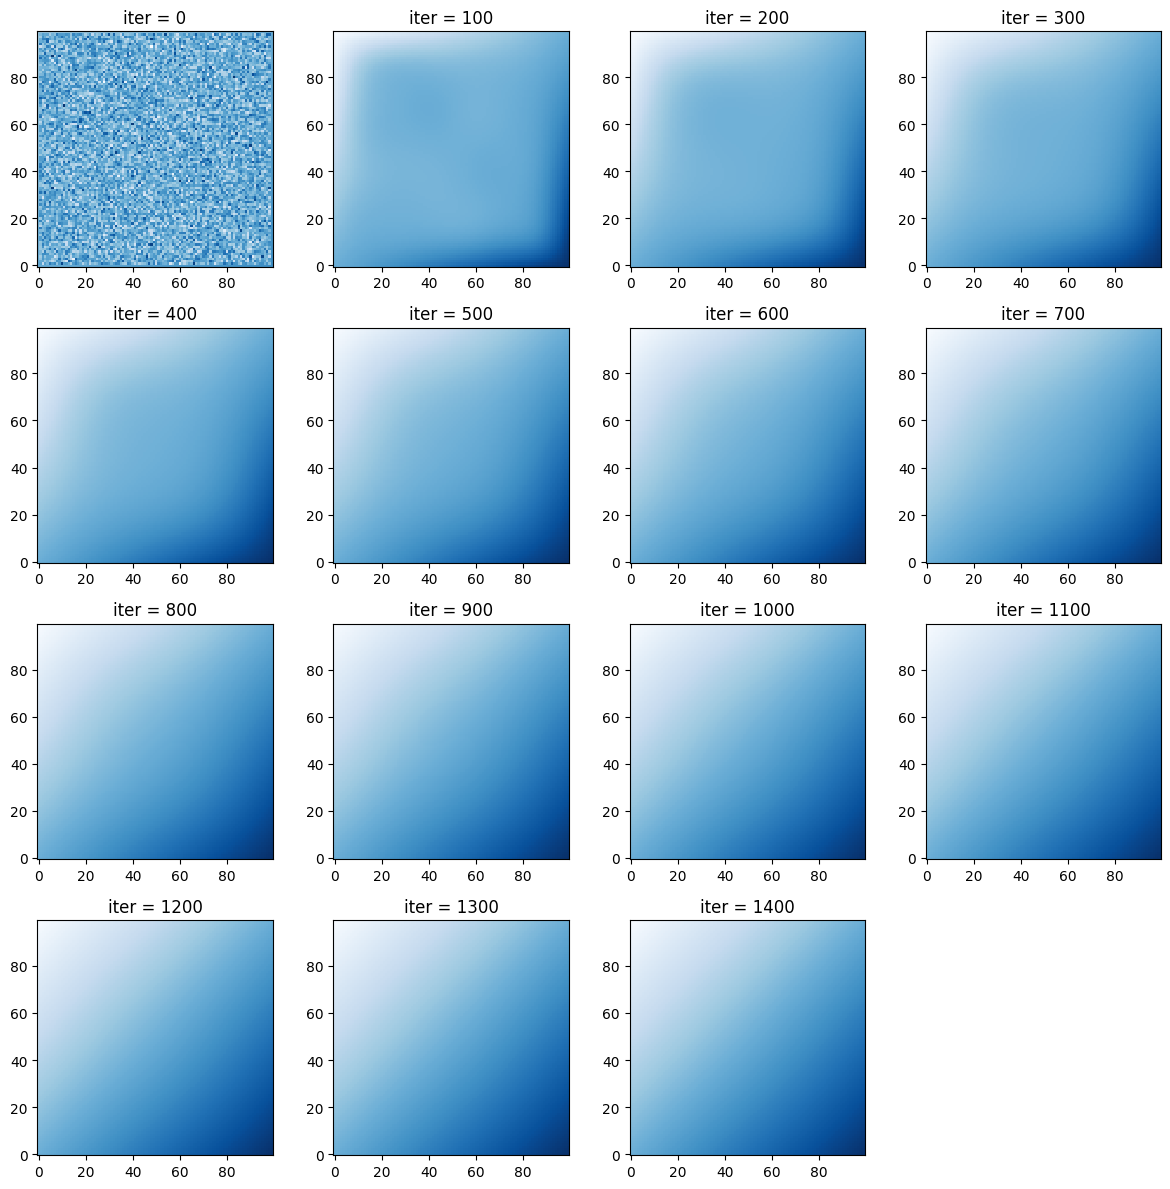

In [10]:
x = initgrid(100)

plt.figure(figsize=(12,12))

for i in range(1500):    
    if i % 100 == 0:
        plt.subplot(4,4,i//100+1)
        showsol(x)
        plt.title('iter = %s' % i)
    x = step(x)

plt.tight_layout()

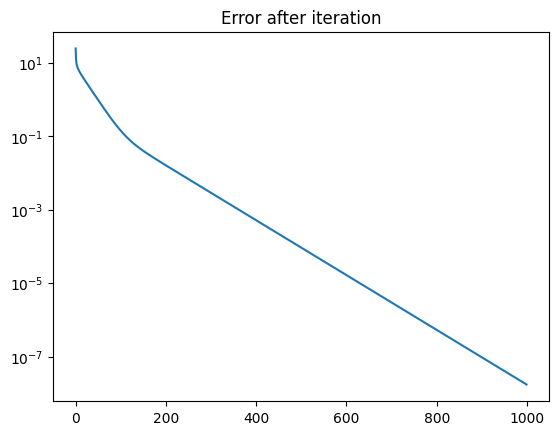

In [11]:
# Посмотрим также на ошибку от временной итерации

x = initgrid(25)
sol = poisson_direct(25, boundary)

err = []

for i in range(1000):    
    err.append((i,np.linalg.norm(x - sol)))
            
    x = step(x)

err = np.array(err)
    
plt.semilogy(err[:,0],err[:,1])
plt.title('Error after iteration');

## Гиперболические уравнения

- Также эволюционный во времени процесс, но можно страктовать отрицательное с.з. как обратное время.
- Решаются как при заданных начальных условиях, так и при краевых.
- "Негладкости" и "разрывы" могут __появляться__ в ходе эволюции (ударная волна). 

Примеры:

- Волновое уравнение

$$
\left(\Delta-\frac{1}{c^2} \frac{\partial^2}{\partial t^2}\right) u=0
$$

- Уравнение переноса (общий вид):

$$
a(t, x, u) \frac{\partial u}{\partial t}+b(t, x, u) \frac{\partial u}{\partial x}+c(t, x, u)=0
$$

Являются самыми тяжелыми для освоения, поэтому в наш курс не входят - это связано с тем, что в решении математически появляются разрывы, с чем метод конечных разностей не очень дружит. Возможно, finite element даст более простой и универсальный подход. 

## Сходимость разностных схем

### Сходимость = Аппроксимация + Устойчивость

__Теорема.__ (Лакса-Рябенького-Филиппова). Пусть разностная задача аппроксимирует дифференциальную задачу на ее решении и устойчива. Тогда решение разностной задачи сходится к решению дифференциальной. 
Если аппроксимация имеет порядок $k$ по времени и порядок р по пространству, то и сходимость имеет те же порядки.

### Аппроксимация

В чистом виде переносится с задачи Коши с поправкой на несколько переменных. Таким образом можно ввести отдельные порядки аппроксимации по разным осям.

__Пример 1.__ Для разнообразия рассмотрим УРЧП первого порядка.

$$
\frac{\partial u}{\partial t} = \frac{\partial u}{\partial x} + f(x, t)
$$

относительно следующей разностной задачи (явная четырёхточечная схема Эйлера):

<p style="text-align:center;"><img src="https://cdn.mathpix.com/snip/images/tvfmqeoFdVuovGkHLEycxqdaI6aqbUFbEIasH8-r0xU.original.fullsize.png" width="300">


$$
\frac{u^{n+1}_j-u^{n}_j}{\tau} = \frac{u^n_{j+1}-u^n_{j-1}}{2\cdot h} + f^n_j
$$


Разложение в ряд Тейлора удобнее всего делать с помощью Wolfram или sympy. Будьте внимательны, в sympy __нет__ надежного способа разложить в ряд Тейлора функцию от нескольких переменных, так что он не подойдёт для всех случаев.

In [12]:
import sympy as sp

# Define the symbolic variables
f, x, t, h, tau = sp.symbols('f x t h tau')

# Define the symbolic function u(x,t)
u = sp.Function('u')(x,t)
f = sp.Function('f')(x,t)


# Define the finite difference scheme for u_t = u_x + f
ut = (u.subs(t, t+tau) - u) / tau
ux = (u.subs(x, x+h) - u.subs(x, x-h)) / (2*h)

# Define the Taylor series expansion of u(x+h,t+tau) and u(x-h,t+tau)
ut_series = sp.series(ut, tau, x0=0, n=4)
ux_series = sp.series(ux, h, x0=0, n=4)
ut_series - ux_series - f

Subs(Derivative(u(x, _xi_2), _xi_2), _xi_2, t) - Subs(Derivative(u(_xi_1, t), _xi_1), _xi_1, x) - f(x, t) + tau*Subs(Derivative(u(x, _xi_2), (_xi_2, 2)), _xi_2, t)/2 + tau**2*Subs(Derivative(u(x, _xi_2), (_xi_2, 3)), _xi_2, t)/6 + tau**3*Subs(Derivative(u(x, _xi_2), (_xi_2, 4)), _xi_2, t)/24 - h**2*Subs(Derivative(u(_xi_1, t), (_xi_1, 3)), _xi_1, x)/6 + O(tau**4) + O(h**4)

Видим, что порядок аппроксимации $O(\tau, h^2)$ - неплохо, но к сожалению, данная схема безусловно неустойчива. 

Аналогичным образом можно находить порядки аппроксимации любых схем (или граничных условий) - будьте разве что внимательны к разложению точек типа $u_{m+1}^{n+1}$, где надо раскладывать одновременно по двум и более параметрам, - в sympy нет встроенных методов для вычисления ряда Тейлора по нескольким переменным. 


__Пример 2.__ Исследования на аппроксимацию схемы расщепления по направлению

Для последней схемы покажем, как определить порядок аппроксимации.

В этой схеме последовательно решаем задачи сначала на ~, потом на $n+1$.

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\mathbf{\Lambda}_1 \tilde{u}_{m l}
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

Хотим всё свести к одному уравнению, члены в котором легко разложить в Тейлора.

Запишем эти уравнения в следующем виде:

$$
\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right) \tilde{u}_{m l}=u_{m l}^n
$$

$$
\left(\mathbf{E}-\tau \boldsymbol{\Lambda}_2\right) u^{n+1}=\tilde{u}_{m l}
$$

Подействуем на обе части второго уравнения оператором $\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right)$:
$$
\begin{aligned}
& \quad\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right)\left(\mathbf{E}-\tau \mathbf{\Lambda}_2\right) u_{m l}^{n+1}=\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right) \tilde{u}_{m l}
\end{aligned}
$$

Так как $\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right) \tilde{u}_{m l}=u_{m l}^n$, то

$$
\left(\mathbf{E}-\tau \boldsymbol{\Lambda}_1\right)\left(\mathbf{E}-\tau \boldsymbol{\Lambda}_2\right) u_{m l}^{n+1}=u_{m l}^n
$$

Раскрывая скобки,

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 u_{m l}^{n+1}+\boldsymbol{\Lambda}_2 u_{m l}^{n+1}-\tau^2 \boldsymbol{\Lambda}_1 \boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

И здесь уже всё разлагаем в Тейлора. Порядок аппроксимации этой схемы $O\left(\tau, h_x^2, h_y^2\right)$.

__Примечание.__ Не забываем об аппроксимации граничных условий. Если они заданы в хитром виде (с производными), то их также надо аппроксимировать с нужным порядком. 

### Анализ устойчивости

__Признак фон Неймана__

- Самый простой в использовании
- Применяется в эволюционных задачах (когда есть явная зависимость от времени). Т.е. для параболических и гиперболических уравнений.

Введем вектор разностного решения для данного временного слоя

$$
\mathbf{y}^n=\left(y_0^n, y_1^n, \ldots, y_M^n\right)^{\mathrm{T}}
$$

Это может быть как одномерный, так и k-мерный массив по пространственным координатам.

Пусть мы сумели (возможно, неединственным образом) представить решение на следующем слое в виде

$$
\mathbf{y}^{n+1}=\mathbf{R}_\tau \mathbf{y}^n+\boldsymbol{\sigma}^n .
$$

Оператор $\mathbf{R}_\tau$ называется __оператором послойного перехода__. 

__Теорема.__ (__спектральный признак устойчивости фон Неймана__). Необходимым условием устойчивости по начальным данным является выполнение следующего неравенства для всех собственных значений оператора перехода $\mathbf{R}_\tau$:

$$
|\lambda| \leq 1
$$

Обычно устойчивость исследуется отдельно для каждой фурьегармоники решения
$$
y_m^n=\lambda^n e^{i \alpha m} .
$$


__Примечание.__ Если условие устойчивости выполнено при любых соотношениях между шагами по времени и пространству, то такие схемы называются __абсолютно__ или __безусловно__ устойчивыми. Если для устойчивости схемы требуется выполнение дополнительного условия, накладывающего определенную связь между изменением шагов по времени и пространству, то такие схемы называются __условно__ устойчивыми.

- __Явный левый уголок__ 

Рассмотрим схему, называемую явный левый уголок для решения одномерного линейного уравнения переноса:

$$
\begin{aligned}
& u_t^{\prime}+c u_x^{\prime}=f(t, x) \text { при } c>0: \\
& \frac{y_m^{n+1}-y_m^n}{\tau}+c \frac{y_m^n-y_{m-1}^n}{h}=f_m^n .
\end{aligned}
$$

Для исследования устойчивости применим спектральный признак.

Подставим $y_m^n=\lambda^n e^{i \alpha m}$ в однородное разностное уравнение, так как из устойчивости по начальным данным следует устойчивость по правой части. В результате получим

$$
\frac{\lambda^{n+1} e^{i \alpha m}-\lambda^n e^{i \alpha m}}{\tau}+c \frac{\lambda^n e^{i \alpha m}-\lambda^n e^{i \alpha(m-1)}}{h}=0 .
$$

Нас интересует нетривиальное решение, поэтому сокращая на общий множитель всех членов $\lambda^n e^{i \alpha}$, получим спектр оператора перехода

$$
\lambda=1-c \tau / h+e^{-i \alpha} c \tau / h .
$$

При различных значениях параметра $\alpha$ получим на комплексной плоскости окружность с центром в точке $\quad(1-c \tau / h, 0)$ радиуса $c \tau / h$. При числе Куранта $c \tau / h \leq 1$ эта окружность лежит внутри единичной (рис. 2.1), тем самым выполнен спектральный признак устойчивости. Таким образом, данная разностная схема является условно устойчивой - она устойчива при (гиперболическом) числе Куранта меньше единицы.

<img src="https://cdn.mathpix.com/snip/images/NEqu_DcwEPsFTaz5iKh-eQ5Dz8Cm8VB3eScjBjXBhyE.original.fullsize.png" width="300">

- __Явная схема__

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\frac{u_{m-1, l}^n-2 u_{m l}^n+u_{m+1, l}^n}{h_x^2}+\frac{u_{m, l-1}^n-2 u_{m l}^n+u_{m, l+1}^n}{h_y^2}
$$

или, в операторном виде,

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 u_{m l}^n+\boldsymbol{\Lambda}_2 u_{m l}^n
$$


Подставим в это уравнение следующую штуку

$$
u_{m l}^n=\lambda^n e^{i \alpha m+i \beta l}, \quad \alpha, \beta \in[0,2 \pi]
$$

Сокращая всё, что сокращается, выражаем $\lambda$:

$$
\lambda\left(\alpha, \beta, \tau, h_x, h_y\right)=1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}-4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}
$$

Дальше надо посмотреть, при каких параметрах $\tau, h_x, h_y$ все наши $\lambda$ (тут получилось только одна лямбда) по модулю не превосходят единицу __равномерно__ по $\alpha$ и $\beta$. Здесь, очевидно,

$$
\tau \leq \frac{1}{2\left(h_x^{-2}+h_y^{-2}\right)}
$$

- __Неявная схема__

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\frac{u_{m-1, l}^{n+1}-2 u_{m l}^{n+1}+u_{m+1, l}^{n+1}}{h_x^2}+\frac{u_{m, l-1}^{n+1}-2 u_{m l}^{n+1}+u_{m, l+1}^{n+1}}{h_y^2}
$$

или, в операторном виде,

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 u_{m l}^{n+1}+\boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

Подставим сюда

$$
u_{m l}^n=\lambda^n e^{i \alpha m+i \beta l}, \quad \alpha, \beta \in[0,2 \pi]
$$

И выразим лямбду

$$
\lambda=\frac{1}{1+4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}}
$$

Видим, что эта лямбда по модулю меньше единицы равномерно по $\alpha$ и $\beta$ при любых $\tau, h_x, h_y$, т.е. она абсолютно устойчива.

- __Схема расщепления по направлению__

В этой схеме последовательно решаем задачи сначала на ~, потом на $n+1$.

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\mathbf{\Lambda}_1 \tilde{u}_{m l}
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

По алгоритму применения спектрального признака, надо подставить

$$
u_{m l}^n=\lambda^n e^{i \alpha m+i \beta l}, \quad \alpha, \beta \in[0,2 \pi]
$$

где явно записан множитель временной эволюции $\lambda^n$.

При переходе на слой ~ тоже аля происходит временная эволюция, поэтому

$$
\tilde{u}_{m l}=\lambda_1 u_{m l}^n
$$

То же верно при переходе со слоя ~ на $n+1$:

$$
u_{m l}^{n+1}=\lambda_2 \tilde{u}_{m l}=\left(\lambda_1 \lambda_2\right) u_{m l}^n
$$

Откуда $\lambda=\lambda_1 \lambda_2$.

Подставим формулы выше в разностные схемы и сократим всё, что сокращается. Итого,

$$
\lambda_1=\frac{1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}}{1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}}, \quad \lambda_2=\frac{1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\beta}{2}}{1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\alpha}{2}}
$$

Окончательный спектр оператора послойного перехода

$$
\lambda\left(\alpha, \beta, \tau, h_x, h_y\right)=\lambda_1 \lambda_2=\frac{\left(1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}\right)\left(1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\beta}{2}\right)}{\left(1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\alpha}{2}\right)\left(1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}\right)}
$$

Легко видим, что эта штука всегда меньше единицы. Т.е. схема безусловно устойчива.

__Примечание.__ В случае переменных коэффициентов можно использовать __принцип замороженных коэффициентов__ - когда мы считаем коэффициенты константными даже при их непостоянности. Часто приводит к неверным результатам, но существенно упрощает выкладки. В остальном же придётся делать оценку устойчивости равномерно по всей области допустимых параметров $t, x, y$.

## Задание краевых условий на криволинейной границе

Для простоты рассмотри двумерный случай с произвольной границей, заданной уравнением 

$$
\varphi(x, y) = 0
$$

Граничное условие на производную вдоль нормали можно следующим образом задать:

\begin{gathered}
\frac{\partial \varphi}{\partial \vec{n}}=0 \\
\frac{\partial \varphi}{\partial \vec{n}}=(\operatorname{grad\varphi }, \vec{n}) \\
\vec{n}=\frac{\left(x-x_0, y-y_0\right)}{\sqrt{\left(x-x_0\right)^2+\left(y-y_0\right)^2}} \\
\operatorname{grad\varphi }=\left(\frac{\partial \varphi}{\partial x}, \frac{\partial \varphi}{\partial y}\right) \\
\frac{\partial \varphi}{\partial x} \simeq\left(\varphi_{i+1, j}-\varphi_{i, j}\right) \frac{1}{\Delta x} \\
\frac{\partial \varphi}{\partial y} \approx\left(\varphi_{i, j+1}-\varphi_{i, j}\right) \cdot \frac{1}{\Delta y}
\end{gathered} 

Отсюда применительно к нашей задаче на кривой границе будем писать:

\begin{aligned}
& \left(u_{i, j}-u_{i+1, j}\right) / h * n_x+\left(u_{i, j}-u_{i, j+1}\right) / h * n_y=0 \\
& u_{i, j}=u_{i+1, j} \cdot n_x+u_{i, j+1} \cdot n_y
\end{aligned}

Граничными точками будем называть такие, для которых внутри рассматриваемой области нет хотя бы одной из 4 соседних. Например, для точки (i, j) соседними будем называть точки  (i+1, j), (i, j+1), (i-1, j), (i, j-1). 

## Домашнее задание

__Задача 1.__
Исследовать на аппроксимацию и устойчивость разностную схему

$$
\begin{aligned}
& \frac{y_k^{n+1}-y_k^n}{\tau}+\frac{a}{2}\left[\frac{y_{k+1}^{n+1}-y_{k-1}^{n+1}}{2 h}+\frac{y_{k+1}^n-y_{k-1}^n}{2 h}\right]=\frac{1}{2}\left(f_k^{n+1}+f_k^n\right), \\
& y_k^0=\varphi\left(x_k\right) \quad k=0, \pm 1, \ldots, n=0,1,2, \ldots
\end{aligned}
$$

для задачи 

$$u_t+a u_x=f(t, x) \quad u(0, x)=\varphi(x) \quad t \geq 0 \quad -\infty<x<\infty$$

Решите численно задачу. 

__Задача 2.__

Построить две разностные схемы для задачи c разными шаблонами
$$
\frac{\partial u}{\partial t}-a^2(x, t) \frac{\partial^2 u}{\partial x^2}=0, \quad u(x, 0)=\psi(x),
$$
Спектральным признаком исследовать полученные схемы на устойчивость, используя принцип замороженных коэффициентов.

__Задача 3.__ Получите с помощью схемы переменных направлений решение двумерной задачи нестационарной теплопроводности в квадрате при следующих начальных и краевых условиях:

$$
\begin{aligned}
& u_t=u_{x x}+u_{y y}+f(x, y, t), \quad 0 \leq x \leq 1, \;0 \leq y \leq 1, \;0<t, \\ \\
& f(x, y, t)=2 \pi^2 \sin (\pi x) \sin (\pi y), \\
& u(0, y, t)=0, \;u(1, y, t)=0, \; u(x, 0, t)=0,\; u(x, 1, t)=0, \;0<t, \\
& u(x, y, 0)=0, \; 0 \leq x \leq 1, \;0 \leq y \leq 1 .
\end{aligned}
$$

Проверьте, что точным решением дифференциальной задачи является $u(x, y, t)=\left(1-\exp \left(-\pi^2 t\right)\right) \sin (\pi x) \sin (\pi y)$. Сгущением сеток и сравнением с сеточной проекцией точного решения покажите, что схема имеет второй порядок сходимости по всем переменным (т.е. проверить порядок аппроксимации __экспериментально__).

__Задача 4.__
Построить разностную схему для решения задачи

$$
\frac{\partial}{\partial x} \left(u \frac{\partial u}{\partial x}\right)+\frac{\partial}{\partial y} \left( u \frac{\partial u}{\partial y}\right)=0
$$

в прямоугольной области $0 \leq x \leq X, 0 \leq y \leq Y$ с граничными условиями 

$$
u(0, y)=1, \quad u(x, Y)=1+x^2, \quad u(X, y)=1+X^2 y / Y, \quad u(x, 0)=1
$$

Какой порядок аппроксимации у данной численной схемы? Является ли это уравнение линейным? Решите задачу.

__Задача 5.**__ Требуется решить двумерное уравнение Пуассона: $u_{x x}+u_{y y}=f(x, y)$, на __многосвязной__ области интегрирования с нулевым начальным приближением и различными граничными условиями первого или второго типа. Граница может быть произвольно заданной замкнутой кривой без самопересечений.

Эта задача с двумя звёздочками - вполне можно за неё одну дать БРСов как за всё задание.